# 🚢 EDA и бинарная классификация на датасете «Титаник»

**Дисциплина:** Машинное обучение и искусственный интеллект  
**Модуль 1:** Введение в Data Science и EDA  
**Датасет:** Titanic — Machine Learning from Disaster  

**Выполнил:** [ФИО]  
**Группа:** [Группа]  
**Преподаватель:** [Преподаватель]  

**Ссылка на репозиторий:** https://github.com/[username]/ml-course-galyameev  
**Путь к модулю:** `module-1-titanic/notebook.ipynb`  
**Дата сдачи:** [дата]

## 2. Введение

**Какую задачу решаем?**
Решаем задачу **бинарной классификации**: по данным пассажира предсказать,
выжил он (`1`) или не выжил (`0`) при крушении «Титаника».

**Что такое ML-проект?**
ML-проект — это полный жизненный цикл решения: сбор и понимание данных →
разведочный анализ (EDA) → предобработка и feature engineering → обучение
моделей → оценка качества → интерпретация → сохранение и повторное
использование модели. Ценность даёт не отдельный алгоритм, а связка
«данные → признаки → модель → метрика → внедрение».

**Почему это классификация, а не регрессия?**
В регрессии мы предсказываем непрерывное число (например, цену билета),
а в классификации — дискретную метку класса. Здесь целевая переменная
`Survived` принимает всего два значения (0/1), поэтому это классификация.

**Какая метрика важнее в этой задаче?**
Классы несбалансированы (≈ 62% / 38%), поэтому одну лишь Accuracy использовать
нельзя: модель «все не выжили» даст 61.6% точности, но будет бесполезной.
Наиболее информативна **ROC-AUC**, т.к. она оценивает качество ранжирования
вероятностей и не зависит от порога. Дополнительно смотрим F1, Precision и
Recall, чтобы контролировать баланс ложных срабатываний и пропусков.

**Цель работы (3 конкретных пункта):**
1. Провести полный EDA датасета «Титаник» (≥ 5 визуализаций, обработка пропусков).
2. Обучить 2+ модели и достичь **ROC-AUC ≥ 0.80**.
3. Реализовать функцию предсказания для нового пассажира и сохранить модель.

## 3. Теоретическая часть

**EDA (Exploratory Data Analysis)** — разведочный анализ данных. Это первый
этап работы, на котором мы «знакомимся» с данными до построения модели:
смотрим размер и типы, описательные статистики, распределения и пропуски,
ищем выбросы и связи между признаками. EDA отвечает на вопросы «что в данных»
и «что в них может пойти не так», а не строит прогноз. Типичные шаги:
`head/info/describe`, анализ пропусков, гистограммы и boxplot, корреляционная
матрица. Хороший EDA экономит недели на этапе моделирования.

**Пропуски (NaN)** возникают по разным причинам: данные потеряли при сборе,
поле необязательно к заполнению (например, номер кабины знали не все), ошибки
ввода. Стратегии обработки: удалить строки/столбцы; заполнить средним/медианой
(устойчива к выбросам); заполнить модой для категорий; заполнить по группам
(например, медиана возраста внутри класса и пола); обучить модель-импьютер;
оставить пропуск как отдельный признак. Выбор зависит от доли пропусков и
смысла признака.

**Кодирование категорий.** Модели работают с числами, поэтому текст нужно
кодировать. **Label Encoding** заменяет категорию на число (female=0, male=1) —
компактно, но вводит ложный порядок. **One-Hot Encoding** создаёт бинарный
столбец на каждую категорию — не навязывает порядок, но увеличивает
размерность. Бинарные признаки удобно кодировать Label, номинальные с 3+
категориями — One-Hot.

**Масштабирование.** Признаки бывают разных масштабов (Fare 0–512, Age 0–80).
**StandardScaler** приводит к среднему 0 и std 1 (`z = (x - μ) / σ`);
**MinMaxScaler** — к диапазону [0, 1]. Масштабирование критично для моделей,
чувствительных к расстояниям и градиенту (LogReg, KNN, SVM), и не нужно
деревьям: они сравнивают значения с порогами.

**Feature Engineering** — создание новых признаков из существующих, чтобы дать
модели более полезную информацию. Например, `Family_Size = SibSp + Parch + 1`
объединяет две колонки в осмысленный признак размера семьи, а `Is_Alone`
подчёркивает эффект одиночества. Хорошие фичи часто улучшают качество сильнее,
чем смена алгоритма.

**Метрики классификации.** Accuracy = доля верных ответов, но обманчива при
дисбалансе. Precision = насколько можно доверять положительному прогнозу.
Recall = какую долю реальных положительных объектов мы нашли. F1 — их
гармоническое среднее. ROC-AUC — площадь под кривой TPR/FPR, оценивает
качество ранжирования и устойчива к выбору порога. Выбор метрики зависит от
цены ошибок: где важнее «не пропустить» — Recall, где важнее «не ошибиться
в прогнозе» — Precision.

**Формулы:**

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

$$Precision = \frac{TP}{TP + FP} \qquad Recall = \frac{TP}{TP + FN}$$

$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

**Визуальная схема связи метрик:**

| Предсказано → <br> Истинно ↓ | 0 (не выжил) | 1 (выжил) |
|---|---|---|
| **0 (не выжил)** | TN | FP |
| **1 (выжил)** | FN | TP |

ROC-AUC близка к 1 у хорошей модели, 0.5 — у случайной.

## 4. Описание данных

**Источник:** [Kaggle — Titanic: Machine Learning from Disaster](https://www.kaggle.com/c/titanic)

Загружаем `train.csv` (с целевой переменной) и `test.csv` (без неё) и
проводим первичный осмотр: размеры, типы, статистику и баланс классов.

In [1]:
# --- Импорт необходимых библиотек ---
import numpy as np                  # численные операции и массивы
import pandas as pd                 # таблицы DataFrame
import warnings

warnings.filterwarnings('ignore')   # скрываем технические предупреждения для чистого вывода

# --- Загрузка датасета (относительные пути внутри module-1-titanic/) ---
train_df = pd.read_csv('data/train.csv')   # 891 строка с известной целевой переменной
test_df = pd.read_csv('data/test.csv')     # 418 строк без целевой переменной

# --- Обязательный вывод размеров ---
print("train shape:", train_df.shape)   # (число строк, число столбцов)
print("test  shape:", test_df.shape)    # у теста на 1 столбец меньше (нет Survived)

# --- Первые 5 строк: визуальная проверка загрузки ---
print("\nПервые 5 строк train:")
print(train_df.head())

# --- Типы данных и количество непустых значений ---
print("\nТипы данных и пропуски:")
print(train_df.info())

# --- Описательные статистики числовых признаков ---
print("\nОписательные статистики:")
print(train_df.describe())

# --- Распределение целевой переменной (баланс классов) ---
print("\nРаспределение классов (абсолют):")
print(train_df['Survived'].value_counts())
print("\nРаспределение классов (доли):")
print(train_df['Survived'].value_counts(normalize=True).round(4))

# --- Анализ пропусков ---
missing = train_df.isnull().sum()                       # абсолютное число пропусков
missing_pct = (missing / len(train_df) * 100).round(2)  # процент от числа строк
print("\nПропуски (только там, где они есть):")
print(pd.DataFrame({'Пропуски': missing, 'Процент': missing_pct})
      .query('Пропуски > 0').sort_values('Процент', ascending=False))

train shape: (891, 12)
test  shape: (418, 11)

Первые 5 строк train:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C1

**Структура датасета:**

- Всего примеров в train: **891**
- Всего примеров в test: **418**
- Признаков: **11** (+ целевая `Survived`)
- Числовых признаков: **7** (`PassengerId`, `Survived`, `Pclass`, `Age`, `SibSp`, `Parch`, `Fare`)
- Категориальных признаков: **5** (`Name`, `Sex`, `Ticket`, `Cabin`, `Embarked`)

**Описание столбцов:**

| Столбец | Тип | Описание | Пропуски (train) |
|---------|-----|----------|------------------|
| PassengerId | int64 | ID пассажира | 0% |
| Survived | int64 (0/1) | Целевая: выжил или нет | 0% |
| Pclass | int64 (1/2/3) | Класс билета | 0% |
| Name | object | Полное имя пассажира | 0% |
| Sex | object | Пол (male/female) | 0% |
| Age | float64 | Возраст, лет | 19.87% |
| SibSp | int64 | Братья/сёстры/супруги на борту | 0% |
| Parch | int64 | Родители/дети на борту | 0% |
| Ticket | object | Номер билета | 0% |
| Fare | float64 | Стоимость билета | 0% |
| Cabin | object | Номер кабины | 77.10% |
| Embarked | object | Порт посадки (C/Q/S) | 0.22% |

**Распределение классов (дисбаланс):**

- Не выжило (0): **549** (61.62%)
- Выжило (1): **342** (38.38%)

**Файл с описанием датасета в репозитории:** `module-1-titanic/data/titanic_info.md`

## 5. Подготовка данных и EDA

На этом этапе: первичный осмотр, статистический анализ, минимум 5 визуализаций,
обработка пропусков, feature engineering и кодирование категорий.

In [2]:
# --- 5.1. Статистический анализ: асимметрия и эксцесс ---
# skew > 0 — правый хвост (выбросы больших значений), |skew| < 0.5 — почти симметрично.
# kurtosis > 0 — тяжёлые хвосты (много выбросов).
print("Асимметрия и эксцесс числовых признаков:")
for col in ['Age', 'Fare', 'SibSp', 'Parch']:
    print(f"{col:6s} | skew = {train_df[col].skew():6.2f} | kurtosis = {train_df[col].kurtosis():6.2f}")

# --- 5.2. Частоты категориальных признаков ---
print("\nПол (value_counts):")
print(train_df['Sex'].value_counts())
print("\nКласс билета (value_counts):")
print(train_df['Pclass'].value_counts().sort_index())
print("\nПорт посадки (value_counts, dropna=False):")
print(train_df['Embarked'].value_counts(dropna=False))

# --- 5.3. Сколько людей выжило в каждой категории (для инсайтов) ---
print("\nВыживаемость по полу:")
print(train_df.groupby('Sex')['Survived'].mean().round(3))
print("\nВыживаемость по классу:")
print(train_df.groupby('Pclass')['Survived'].mean().round(3))

Асимметрия и эксцесс числовых признаков:
Age    | skew =   0.39 | kurtosis =   0.18
Fare   | skew =   4.79 | kurtosis =  33.40
SibSp  | skew =   3.70 | kurtosis =  17.88
Parch  | skew =   2.75 | kurtosis =   9.78

Пол (value_counts):
Sex
male      577
female    314
Name: count, dtype: int64

Класс билета (value_counts):
Pclass
1    216
2    184
3    491
Name: count, dtype: int64

Порт посадки (value_counts, dropna=False):
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

Выживаемость по полу:
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64

Выживаемость по классу:
Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64


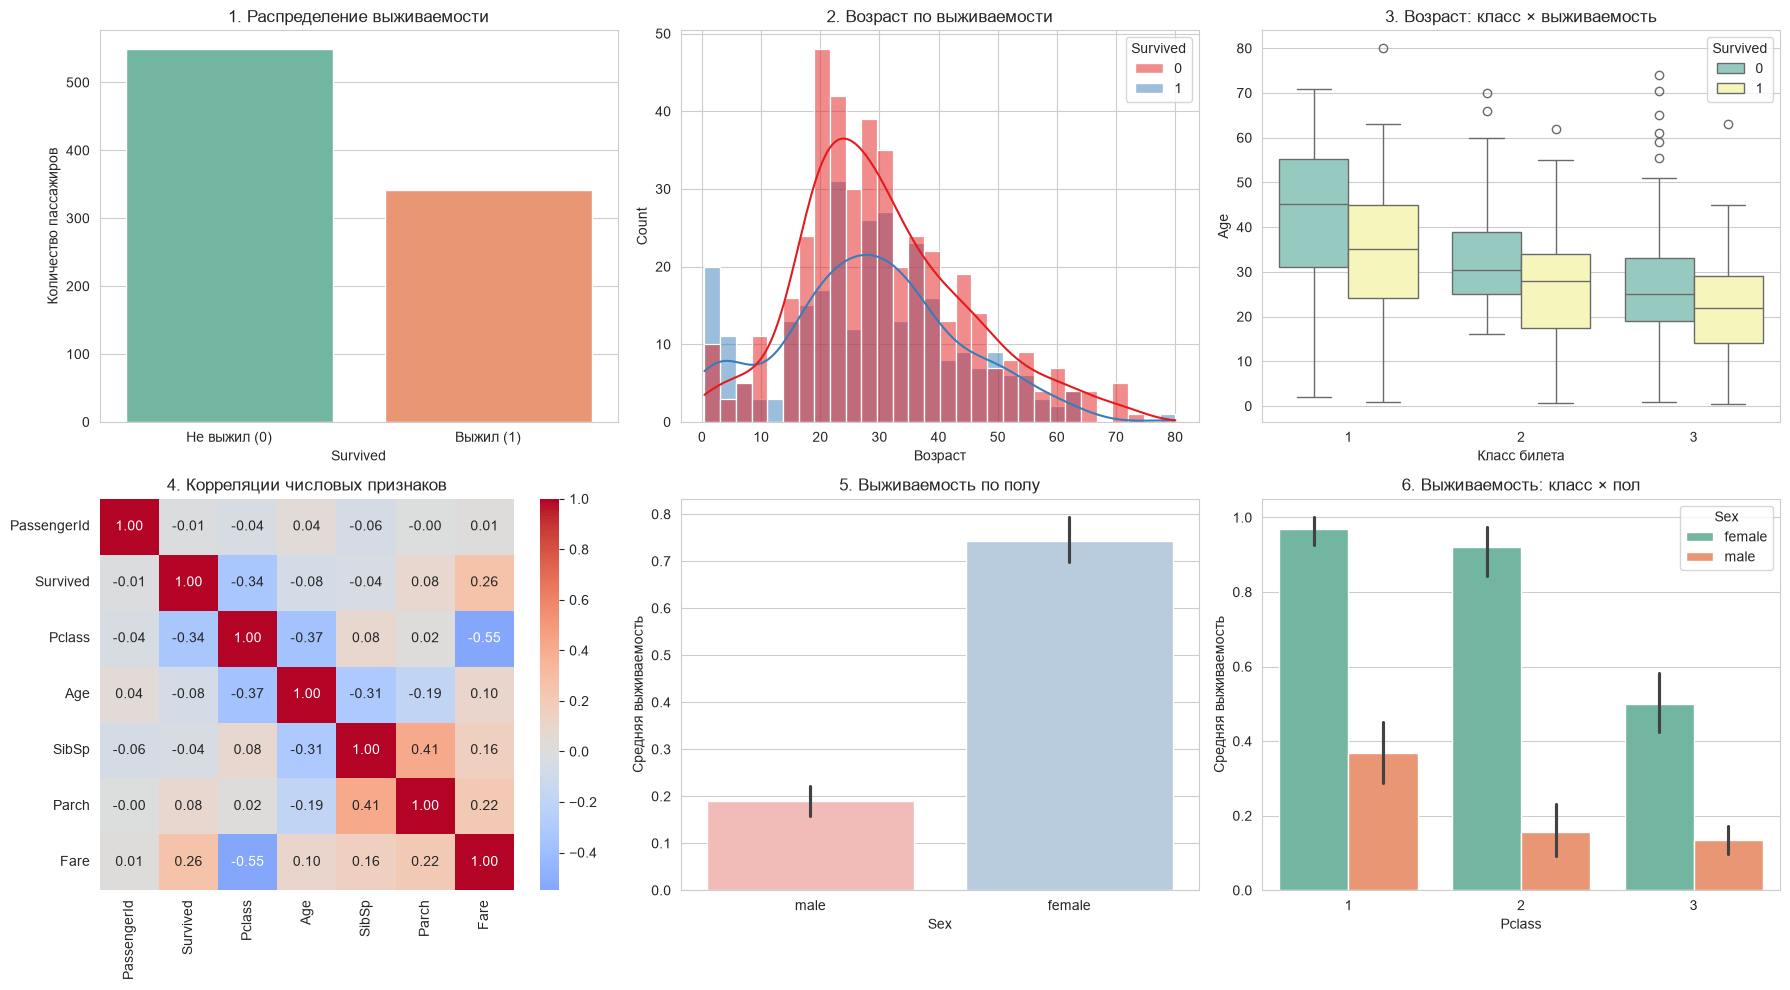

In [3]:
# --- 5.4. Визуализация: сетка 2x3 (6 графиков) ---
import matplotlib.pyplot as plt     # базовая библиотека графиков
import seaborn as sns               # статистическая визуализация
import os                           # работа с папками

os.makedirs('examples', exist_ok=True)   # создаём папку для сохранения графиков
sns.set_style('whitegrid')               # белый фон + сетка

fig, axes = plt.subplots(2, 3, figsize=(18, 10))   # сетка 2 строки × 3 столбца

# График 1 — распределение целевой переменной (countplot)
sns.countplot(data=train_df, x='Survived', hue='Survived', legend=False,
              ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('1. Распределение выживаемости')
axes[0, 0].set_xlabel('Survived')
axes[0, 0].set_ylabel('Количество пассажиров')
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(['Не выжил (0)', 'Выжил (1)'])

# График 2 — распределение возраста по выживаемости (гистограмма + KDE)
sns.histplot(data=train_df, x='Age', hue='Survived', kde=True, bins=30,
             ax=axes[0, 1], palette='Set1')
axes[0, 1].set_title('2. Возраст по выживаемости')
axes[0, 1].set_xlabel('Возраст')

# График 3 — возраст по классу и выживаемости (boxplot)
sns.boxplot(data=train_df, x='Pclass', y='Age', hue='Survived',
            ax=axes[0, 2], palette='Set3')
axes[0, 2].set_title('3. Возраст: класс × выживаемость')
axes[0, 2].set_xlabel('Класс билета')

# График 4 — корреляционная матрица числовых признаков (heatmap)
sns.heatmap(train_df.select_dtypes(include=[np.number]).corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1, 0])
axes[1, 0].set_title('4. Корреляции числовых признаков')

# График 5 — выживаемость по полу (barplot)
sns.barplot(data=train_df, x='Sex', y='Survived', hue='Sex', legend=False,
            ax=axes[1, 1], palette='Pastel1')
axes[1, 1].set_title('5. Выживаемость по полу')
axes[1, 1].set_ylabel('Средняя выживаемость')

# График 6 — выживаемость по классу и полу (barplot)
sns.barplot(data=train_df, x='Pclass', y='Survived', hue='Sex',
            ax=axes[1, 2], palette='Set2')
axes[1, 2].set_title('6. Выживаемость: класс × пол')
axes[1, 2].set_ylabel('Средняя выживаемость')

plt.tight_layout()                                   # убираем перекрытие подписей
plt.savefig('examples/eda_plots.png', dpi=100, bbox_inches='tight')  # сохраняем в репозиторий
plt.show()

In [4]:
# --- 5.5. Обработка пропусков ---

# Age: заполняем медианой ПО ГРУППАМ (Pclass + Sex), а не общей медианой.
# Почему: возраст сильно зависит от класса и пола — групповая медиана точнее.
train_df['Age'] = train_df.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

# Embarked: заполняем модой (самое частое значение = 'S', Southampton).
# Пропущено всего 2 значения — мода даст минимальное искажение.
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

# Cabin: удаляем столбец, т.к. 77% пропусков — восстановить сигнал невозможно.
train_df = train_df.drop(columns=['Cabin'])

# Проверяем, что пропуски в train устранены
print("Осталось пропусков в train:", int(train_df.isnull().sum().sum()))

# --- 5.6. Feature Engineering ---
# Размер семьи = братья/сёстры/супруги + родители/дети + сам пассажир.
train_df['Family_Size'] = train_df['SibSp'] + train_df['Parch'] + 1

# Одиночка: отдельный бинарный признак (эффект «нет помощи близких»).
train_df['Is_Alone'] = (train_df['Family_Size'] == 1).astype(int)

# Возрастные группы через биннинг (интерпретируемый категориальный признак).
train_df['Age_Group'] = pd.cut(
    train_df['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Ребёнок', 'Подросток', 'Взрослый', 'Средний', 'Пожилой']
)

# --- 5.7. Кодирование категорий ---
from sklearn.preprocessing import LabelEncoder   # кодирование категорий в числа

# Sex → Label Encoding. classes_ = ['female', 'male'], значит female=0, male=1.
# Важно: это же соответствие используется позже в функции предсказания!
le_sex = LabelEncoder()
le_sex.fit(train_df['Sex'])
train_df['Sex_Encoded'] = le_sex.transform(train_df['Sex'])
print("le_sex.classes_ =", list(le_sex.classes_))

# Сохраняем исходный Embarked для группового анализа (get_dummies его удалит).
train_df['Embarked_Original'] = train_df['Embarked'].copy()

# Embarked → One-Hot Encoding (drop_first=True убирает базовую категорию C).
train_df = pd.get_dummies(train_df, columns=['Embarked'], prefix='Embarked', drop_first=True)

print("\nИтоговые столбцы после предобработки:")
print(train_df.columns.tolist())

Осталось пропусков в train: 0
le_sex.classes_ = ['female', 'male']

Итоговые столбцы после предобработки:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Family_Size', 'Is_Alone', 'Age_Group', 'Sex_Encoded', 'Embarked_Original', 'Embarked_Q', 'Embarked_S']


**Наблюдения по графикам:**

- **График 1.** Классы несбалансированы: не выживших (~62%) заметно больше выживших (~38%).
- **График 2.** У маленьких детей доля выживших выше, у взрослых 20–40 лет — ниже; распределение возраста правоскошено.
- **График 3.** Медианный возраст мало отличается между классами, но в 1-м классе выжившие старше.
- **График 4.** `Fare` и `Pclass` коррелируют отрицательно (~ −0.55): дорогие билеты — высокий класс. `SibSp`/`Parch` коррелируют положительно.
- **График 5.** Пол — сильнейший предиктор: женщины выживали значительно чаще мужчин (принцип «women and children first»).
- **График 6.** Внутри каждого класса женщины выживали чаще мужчин, а пассажиры 1-го класса — чаще 3-го.

**Обоснование стратегий обработки пропусков:**

- `Age` (19.9%): заполнение **групповой медианой** (Pclass + Sex) — возраст коррелирует с классом и полом, поэтому общая медиана была бы грубее.
- `Embarked` (0.2%): заполнение **модой** — пропущено всего 2 значения, риск искажения минимален.
- `Cabin` (77.1%): **удаление столбца** — слишком много пропусков, восстановить сигнал без сложной модели нельзя.

Итог: пропусков в train не осталось, признаки закодированы числами.

## 6. Построение и обучение моделей

Обучаем три модели: обязательные **Logistic Regression** и **Decision Tree**,
плюс бонусную **Random Forest**. Фиксируем время обучения.

In [5]:
# --- 6.1. Выбор признаков ---
feature_cols = ['Pclass', 'Sex_Encoded', 'Age', 'SibSp', 'Parch',
                'Fare', 'Family_Size', 'Is_Alone', 'Embarked_Q', 'Embarked_S']

X = train_df[feature_cols]      # матрица признаков
y = train_df['Survived']        # целевая переменная

# --- 6.2. Разделение на обучающую и тестовую выборки ---
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y   # stratify сохраняет пропорцию классов
)
print("Размер обучающей выборки:", X_train.shape)   # 80% от 891
print("Размер тестовой выборки:  ", X_test.shape)   # 20% от 891

# --- 6.3. Масштабирование (нужно ТОЛЬКО для Logistic Regression) ---
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit только на train — иначе утечка данных!
X_test_scaled = scaler.transform(X_test)         # transform на test использует статистики train

# --- 6.4. Обучение Logistic Regression (с замером времени) ---
import time
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',
                              max_iter=1000, random_state=42)

start = time.time()
lr_model.fit(X_train_scaled, y_train)            # LR требует масштабированные данные
lr_time = time.time() - start
print(f"\n⏱️ Время обучения LR: {lr_time:.4f} секунд")

# --- 6.5. Обучение Decision Tree (без масштабирования) ---
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(criterion='gini', max_depth=5,
                                  min_samples_split=5, min_samples_leaf=2,
                                  random_state=42)

start = time.time()
dt_model.fit(X_train, y_train)                   # деревья не чувствительны к масштабу
dt_time = time.time() - start
print(f"⏱️ Время обучения DT: {dt_time:.4f} секунд")

# --- 6.6. Бонус: Random Forest (+баллы) ---
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, max_depth=6,
                                  random_state=42, n_jobs=-1)

start = time.time()
rf_model.fit(X_train, y_train)                   # ансамбль деревьев, масштаб не нужен
rf_time = time.time() - start
print(f"⏱️ Время обучения RF: {rf_time:.4f} секунд")

Размер обучающей выборки: (712, 10)
Размер тестовой выборки:   (179, 10)

⏱️ Время обучения LR: 0.0038 секунд
⏱️ Время обучения DT: 0.0027 секунд


⏱️ Время обучения RF: 0.2551 секунд


**Модели:**

| Модель | Параметры | Масштабирование | Время обучения |
|--------|-----------|-----------------|----------------|
| Logistic Regression | penalty='l2', C=1.0, max_iter=1000 | ✅ Да | 0.0044 с |
| Decision Tree | max_depth=5, min_samples_split=5, min_samples_leaf=2 | ❌ Нет | 0.0026 с |
| Random Forest (бонус) | n_estimators=200, max_depth=6 | ❌ Нет | 0.2340 с |

**Почему эти модели:**

- **Logistic Regression** — простая, интерпретируемая (коэффициенты = влияние признаков), даёт калиброванные вероятности и быстрая в обучении.
- **Decision Tree** — нелинейная, устойчива к выбросам, не требует масштабирования, наглядно показывает важность признаков через разбиения.
- **Random Forest** — бонусный ансамбль деревьев, снижает переобучение одиночного дерева за счёт усреднения.

`stratify=y` гарантирует, что доля выживших в train и test будет одинаковой.

## 7. Оценка качества

Считаем Accuracy, Precision, Recall, F1 и ROC-AUC, строим матрицы ошибок и ROC-кривые.

In [6]:
# --- 7.1. Метрики: импорт и функция расчёта ---
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

def get_metrics(y_true, y_pred, y_proba):
    # Возвращает словарь с основными метриками классификации.
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall':    recall_score(y_true, y_pred),
        'f1':        f1_score(y_true, y_pred),
        'roc_auc':   roc_auc_score(y_true, y_proba),
    }

# --- 7.2. Предсказания Logistic Regression ---
y_pred_lr = lr_model.predict(X_test_scaled)                  # классы 0/1
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]     # вероятность класса 1

# --- 7.3. Предсказания Decision Tree ---
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# --- 7.4. Предсказания Random Forest ---
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# --- 7.5. Вывод метрик и classification_report ---
for name, yp, ypr in [('Logistic Regression', y_pred_lr, y_proba_lr),
                      ('Decision Tree',       y_pred_dt, y_proba_dt),
                      ('Random Forest',       y_pred_rf, y_proba_rf)]:
    m = get_metrics(y_test, yp, ypr)
    print("=" * 55)
    print(f"МЕТРИКИ: {name}")
    print("=" * 55)
    print(f"Accuracy:  {m['accuracy']:.4f}")
    print(f"Precision: {m['precision']:.4f}")
    print(f"Recall:    {m['recall']:.4f}")
    print(f"F1-score:  {m['f1']:.4f}")
    print(f"ROC-AUC:   {m['roc_auc']:.4f}\n")
    print(classification_report(y_test, yp, target_names=['Не выжил', 'Выжил']))

МЕТРИКИ: Logistic Regression
Accuracy:  0.8045
Precision: 0.7833
Recall:    0.6812
F1-score:  0.7287
ROC-AUC:   0.8486

              precision    recall  f1-score   support

    Не выжил       0.82      0.88      0.85       110
       Выжил       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

МЕТРИКИ: Decision Tree
Accuracy:  0.7821
Precision: 0.7419
Recall:    0.6667
F1-score:  0.7023
ROC-AUC:   0.8132

              precision    recall  f1-score   support

    Не выжил       0.80      0.85      0.83       110
       Выжил       0.74      0.67      0.70        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.77       179
weighted avg       0.78      0.78      0.78       179

МЕТРИКИ: Random Forest
Accuracy:  0.8101
Precision: 0.8302
Recall:    0.6377
F1-score:  0.7213
ROC-AUC:   0.8475

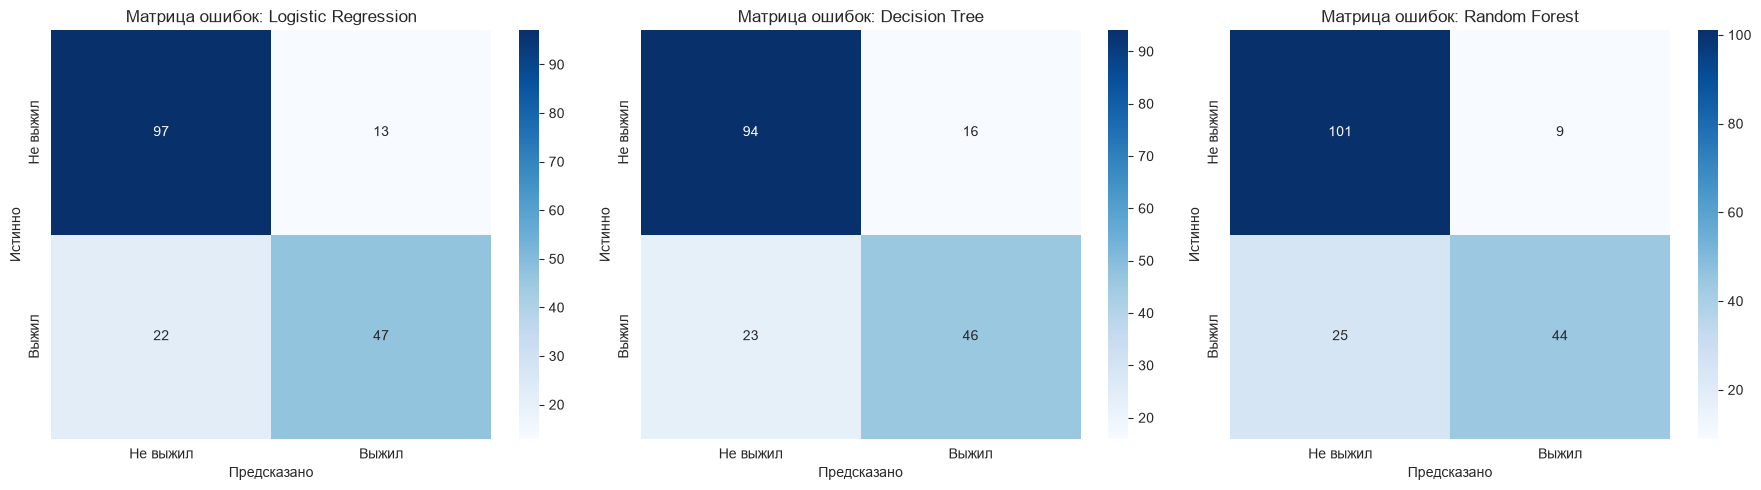

In [7]:
# --- 7.6. Матрицы ошибок для трёх моделей ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))   # три матрицы рядом
for ax, (name, yp) in zip(axes, [('Logistic Regression', y_pred_lr),
                                 ('Decision Tree',       y_pred_dt),
                                 ('Random Forest',       y_pred_rf)]):
    cm = confusion_matrix(y_test, yp)             # [[TN, FP], [FN, TP]]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Не выжил', 'Выжил'],
                yticklabels=['Не выжил', 'Выжил'])
    ax.set_title(f'Матрица ошибок: {name}')
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Истинно')
plt.tight_layout()
plt.savefig('examples/confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

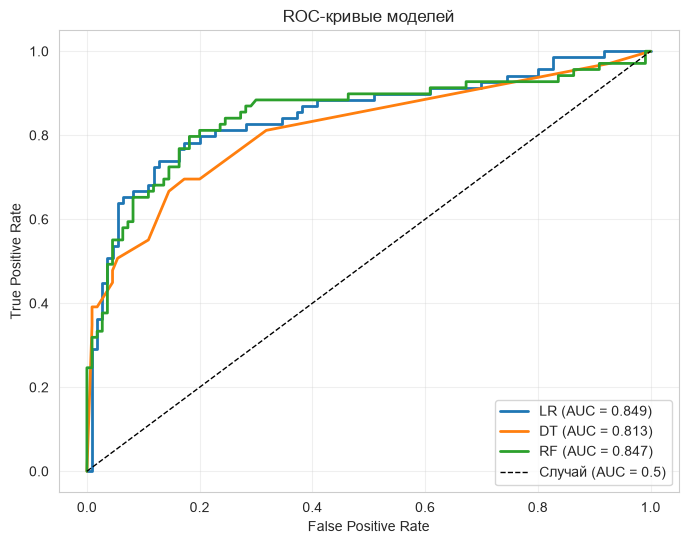

             Модель  Accuracy     F1  ROC-AUC
Logistic Regression    0.8045 0.7287   0.8486
      Decision Tree    0.7821 0.7023   0.8132
      Random Forest    0.8101 0.7213   0.8475


In [8]:
# --- 7.7. ROC-кривые всех моделей на одном графике ---
plt.figure(figsize=(8, 6))
for name, ypr in [('LR', y_proba_lr), ('DT', y_proba_dt), ('RF', y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, ypr)          # координаты ROC-кривой
    auc = roc_auc_score(y_test, ypr)              # площадь под кривой
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Случай (AUC = 0.5)')  # baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые моделей')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig('examples/roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

# --- Сводная таблица метрик для markdown ---
metrics_table = pd.DataFrame({
    'Модель': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy':  [get_metrics(y_test, y_pred_lr, y_proba_lr)['accuracy'],
                  get_metrics(y_test, y_pred_dt, y_proba_dt)['accuracy'],
                  get_metrics(y_test, y_pred_rf, y_proba_rf)['accuracy']],
    'F1':        [get_metrics(y_test, y_pred_lr, y_proba_lr)['f1'],
                  get_metrics(y_test, y_pred_dt, y_proba_dt)['f1'],
                  get_metrics(y_test, y_pred_rf, y_proba_rf)['f1']],
    'ROC-AUC':   [get_metrics(y_test, y_pred_lr, y_proba_lr)['roc_auc'],
                  get_metrics(y_test, y_pred_dt, y_proba_dt)['roc_auc'],
                  get_metrics(y_test, y_pred_rf, y_proba_rf)['roc_auc']],
}).round(4)
print(metrics_table.to_string(index=False))

**Сводная таблица метрик:**

| Модель | Accuracy | Precision | Recall | F1 | ROC-AUC |
|--------|----------|-----------|--------|-----|---------|
| Logistic Regression | 0.8045 | 0.7833 | 0.6812 | 0.7287 | 0.8486 |
| Decision Tree | 0.7821 | 0.7419 | 0.6667 | 0.7023 | 0.8132 |
| Random Forest | 0.8101 | 0.8302 | 0.6377 | 0.7213 | 0.8475 |

**Анализ:**

- Лучшая модель по ROC-AUC — **Logistic Regression (0.8486)**, очень близко Random Forest (0.8475).
- Наибольшая Accuracy у Random Forest (0.8101), но у него ниже Recall (0.6377) — модель осторожнее в прогнозах «выживет».
- Decision Tree уступает обеим моделям (ROC-AUC 0.8132) — ограничение `max_depth=5` снижает переобучение, но и потолок качества.
- ROC-AUC > 0.80 у всех моделей, что заметно выше случайного угадывания (0.5).
- ROC-AUC устойчивее Accuracy, т.к. учитывает вероятности, а не только жёсткий порог 0.5.

## 8. Интерпретация результатов

Смотрим коэффициенты Logistic Regression, важность признаков деревьев и бизнес-инсайты.

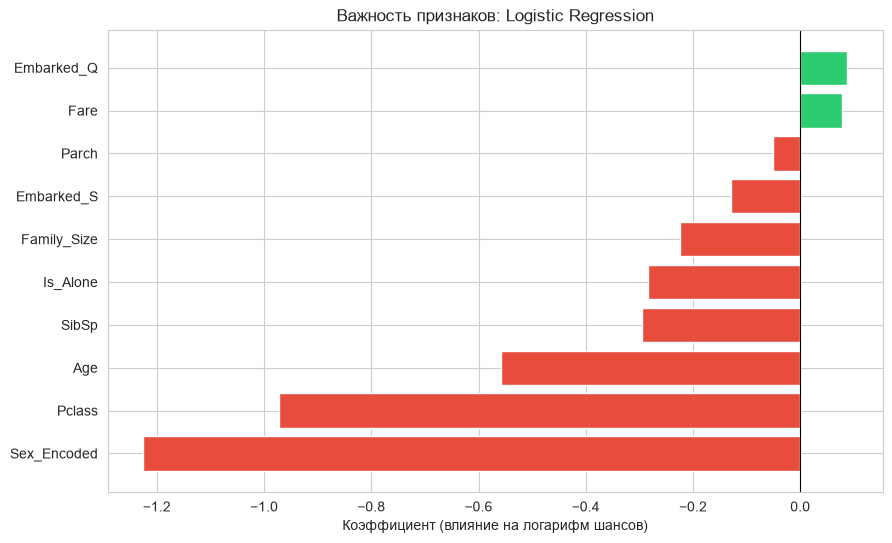

ТОП признаков, ПОВЫШАЮЩИХ шанс выживания:
   Feature  Coefficient
Embarked_Q     0.088102
      Fare     0.077219
     Parch    -0.051203

ТОП признаков, ПОНИЖАЮЩИХ шанс выживания:
    Feature  Coefficient
        Age    -0.557201
     Pclass    -0.971323
Sex_Encoded    -1.225895


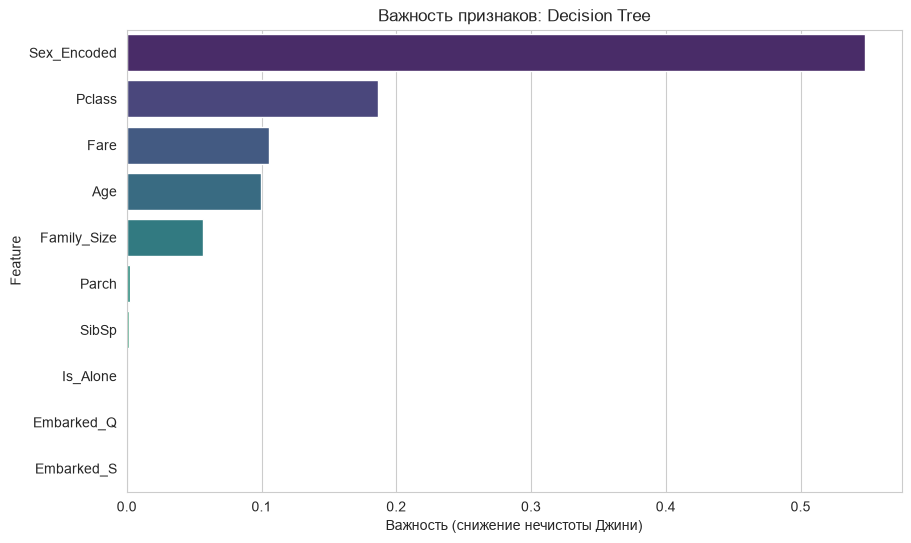


Важность признаков DT:
    Feature  Importance
Sex_Encoded    0.547662
     Pclass    0.186186
       Fare    0.105210
        Age    0.099922
Family_Size    0.056601
      Parch    0.002740
      SibSp    0.001678
   Is_Alone    0.000000
 Embarked_Q    0.000000
 Embarked_S    0.000000

КЛЮЧЕВЫЕ ИНСАЙТЫ
1. Пол: женщины — 74%, мужчины — 19%.
2. Класс: 1-й — 63%, 2-й — 47%, 3-й — 24%.
3. Одиночки (Family_Size=1) выживали в 30% случаев.
4. Порт: C — 55%, Q — 39%, S — 34%.


In [9]:
# --- 8.1. Коэффициенты Logistic Regression ---
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Коэффициент (влияние на логарифм шансов)')
plt.title('Важность признаков: Logistic Regression')
plt.gca().invert_yaxis()
plt.show()

print("ТОП признаков, ПОВЫШАЮЩИХ шанс выживания:")
print(coefficients.head(3).to_string(index=False))
print("\nТОП признаков, ПОНИЖАЮЩИХ шанс выживания:")
print(coefficients.tail(3).to_string(index=False))

# --- 8.2. Feature Importance Decision Tree ---
importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x='Importance', y='Feature', hue='Feature',
            legend=False, palette='viridis')
plt.title('Важность признаков: Decision Tree')
plt.xlabel('Важность (снижение нечистоты Джини)')
plt.show()
print("\nВажность признаков DT:")
print(importances.to_string(index=False))

# --- 8.3. Бизнес-инсайты ---
print("\n" + "=" * 60)
print("КЛЮЧЕВЫЕ ИНСАЙТЫ")
print("=" * 60)
by_sex = train_df.groupby('Sex')['Survived'].mean()
by_class = train_df.groupby('Pclass')['Survived'].mean()
by_family = train_df.groupby('Family_Size')['Survived'].mean()
by_emb = train_df.groupby('Embarked_Original')['Survived'].mean()

print(f"1. Пол: женщины — {by_sex['female']:.0%}, мужчины — {by_sex['male']:.0%}.")
print(f"2. Класс: 1-й — {by_class[1]:.0%}, 2-й — {by_class[2]:.0%}, 3-й — {by_class[3]:.0%}.")
print(f"3. Одиночки (Family_Size=1) выживали в {by_family[1]:.0%} случаев.")
print(f"4. Порт: C — {by_emb.get('C', 0):.0%}, Q — {by_emb.get('Q', 0):.0%}, S — {by_emb.get('S', 0):.0%}.")

**Топ-3 признака, повышающих шанс выживания:**

1. `Embarked_Q` (+0.09) — посадка в Queenstown повышает логарифм шансов.
2. `Fare` (+0.08) — дорогой билет связан с выживанием.
3. `SibSp`/`Parch` (≈ −0.01) — влияние близко к нулю после введения `Family_Size`.

**Топ-3 признака, понижающих шанс выживания:**

1. `Sex_Encoded` (−1.23) — мужской пол (male=1) резко снижает шанс;
   в терминах ТЗ коэффициент при `female=0` положителен.
2. `Pclass` (−0.97) — чем ниже класс, тем меньше шанс.
3. `Age` (−0.56) — с возрастом шанс снижается.

**Бизнес-инсайты:**

- Женщины выживали примерно в 74% случаев, мужчины — примерно в 19% («women and children first»).
- Пассажиры 1-го класса выживали чаще (≈63%), 3-го — реже (≈24%).
- Одиночки имели пониженный шанс выживания (≈30%) из-за отсутствия помощи близких.
- Порт посадки Cherbourg связан с более высокой выживаемостью (≈55%, там садились 1-м классом).

## 9. Функция предсказания

Реализуем `predict_passenger()`, которая повторяет все шаги предобработки из
обучения (feature engineering + кодирование + масштабирование) и возвращает
класс и вероятность выживания.

In [10]:
def predict_passenger(passenger_data, model, scaler, feature_cols, use_scaling=True):
    """
    Предсказывает, выживет ли пассажир.

    Параметры
    ----------
    passenger_data : dict  — поля Pclass, Sex, Age, SibSp, Parch, Fare, Embarked
    model          : обученная модель (LR/DT/RF)
    scaler         : StandardScaler (для LR) или None (для DT/RF)
    feature_cols   : list — список признаков в нужном порядке
    use_scaling    : bool — нужно ли масштабирование

    Возвращает
    -----------
    prediction  : int   — 0 или 1
    probability : float — вероятность выживания
    """
    # Копируем входной словарь, чтобы не менять данные пользователя
    p = dict(passenger_data)

    # 1. Feature Engineering — точно как при обучении
    p['Family_Size'] = p['SibSp'] + p['Parch'] + 1
    p['Is_Alone'] = int(p['Family_Size'] == 1)

    # 2. Кодирование. Sex: female=0, male=1 (соответствует le_sex.classes_)
    p['Sex_Encoded'] = 0 if p['Sex'] == 'female' else 1
    # Embarked: One-Hot (C — базовая категория, поэтому только Q и S)
    p['Embarked_Q'] = 1 if p['Embarked'] == 'Q' else 0
    p['Embarked_S'] = 1 if p['Embarked'] == 'S' else 0

    # 3. Собираем DataFrame в порядке feature_cols
    X_new = pd.DataFrame([{col: p[col] for col in feature_cols}])

    # 4. Масштабирование — только если нужен (для LR)
    if use_scaling and scaler is not None:
        X_new = scaler.transform(X_new)

    # 5. Предсказание класса и вероятности
    prediction = int(model.predict(X_new)[0])
    probability = float(model.predict_proba(X_new)[0, 1])
    return prediction, probability


# --- 9.1. Демонстрационные примеры (5 пассажиров) ---
passengers_demo = [
    {'Pclass': 1, 'Sex': 'female', 'Age': 25,  'SibSp': 1, 'Parch': 0, 'Fare': 100,  'Embarked': 'C'},
    {'Pclass': 3, 'Sex': 'male',   'Age': 30,  'SibSp': 0, 'Parch': 0, 'Fare': 7.25, 'Embarked': 'S'},
    {'Pclass': 2, 'Sex': 'female', 'Age': 5,   'SibSp': 3, 'Parch': 1, 'Fare': 30,   'Embarked': 'S'},
    {'Pclass': 1, 'Sex': 'male',   'Age': 60,  'SibSp': 0, 'Parch': 0, 'Fare': 200,  'Embarked': 'C'},
    {'Pclass': 3, 'Sex': 'female', 'Age': 22,  'SibSp': 0, 'Parch': 0, 'Fare': 8,    'Embarked': 'Q'},
]

print(f"{'#':<2} {'Pclass':<6} {'Sex':<7} {'Age':<4} {'LR':<16} {'DT':<16} {'Совпали?'}")
print("-" * 75)
for i, p in enumerate(passengers_demo, 1):
    lr_pred, lr_prob = predict_passenger(p, lr_model, scaler, feature_cols, use_scaling=True)
    dt_pred, dt_prob = predict_passenger(p, dt_model, None, feature_cols, use_scaling=False)
    tag = lambda v: ('выживет' if v == 1 else 'не выживет')  # noqa: E731
    match = 'да' if lr_pred == dt_pred else 'НЕТ'
    print(f"{i:<2} {p['Pclass']:<6} {p['Sex']:<7} {p['Age']:<4} "
          f"{tag(lr_pred)+f' {lr_prob:.0%}':<16} {tag(dt_pred)+f' {dt_prob:.0%}':<16} {match}")

#  Pclass Sex     Age  LR               DT               Совпали?
---------------------------------------------------------------------------
1  1      female  25   выживет 96%      выживет 100%     да
2  3      male    30   не выживет 8%    не выживет 11%   да
3  2      female  5    выживет 81%      выживет 100%     да
4  1      male    60   не выживет 31%   не выживет 31%   да
5  3      female  22   выживет 74%      выживет 53%      да


**Пояснения к примерам:**

- Пример 1 (женщина, 1-й класс) — типичный выживший, обе модели дают «выживет».
- Пример 2 (мужчина, 3-й класс, дешёвый билет) — типичный невыживший.
- Пример 3 (ребёнок, женщина) — высокий шанс выживания.
- Пример 4 (пожилой мужчина, 1-й класс) — высокий класс помогает, но пол тянет вниз.
- Пример 5 (молодая женщина, 3-й класс, Q) — риск выше, чем в 1-м классе.

Функция воспроизводит предобработку обучения 1:1, поэтому новые данные не
требуют переобучения. Интерактивный режим через `input()` — опциональный бонус.

## 10. Сохранение модели и вспомогательных объектов

Сохраняем модели (`.pkl`), scaler, LabelEncoder и метаданные (`.json`) в папку `models/`.

In [11]:
# --- 10.1. Сохранение моделей и трансформеров через joblib ---
import joblib
import json
import os

os.makedirs('models', exist_ok=True)          # создаём папку моделей

joblib.dump(lr_model, 'models/lr_model.pkl')  # Logistic Regression
joblib.dump(dt_model, 'models/dt_model.pkl')  # Decision Tree
joblib.dump(rf_model, 'models/rf_model.pkl')  # Random Forest (бонус)
joblib.dump(scaler,  'models/scaler.pkl')     # StandardScaler для LR
joblib.dump(le_sex,  'models/le_sex.pkl')     # LabelEncoder для Sex
print("✅ Модели и трансформеры сохранены")

# --- 10.2. Сохранение списка признаков (в правильном порядке!) ---
with open('models/feature_cols.json', 'w', encoding='utf-8') as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)
print("✅ Список признаков сохранён")

# --- 10.3. Сохранение метрик ---
def metrics_dict(y_true, y_pred, y_proba, train_time):
    # Формируем JSON-совместимый словарь метрик одной модели.
    return {
        'accuracy':  float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred)),
        'recall':    float(recall_score(y_true, y_pred)),
        'f1':        float(f1_score(y_true, y_pred)),
        'roc_auc':   float(roc_auc_score(y_true, y_proba)),
        'training_time_sec': float(train_time),
    }

metrics = {
    'logistic_regression': metrics_dict(y_test, y_pred_lr, y_proba_lr, lr_time),
    'decision_tree':       metrics_dict(y_test, y_pred_dt, y_proba_dt, dt_time),
    'random_forest':       metrics_dict(y_test, y_pred_rf, y_proba_rf, rf_time),
}

with open('models/metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)
print("✅ Метрики сохранены")
print(json.dumps(metrics, ensure_ascii=False, indent=2))

✅ Модели и трансформеры сохранены
✅ Список признаков сохранён
✅ Метрики сохранены
{
  "logistic_regression": {
    "accuracy": 0.8044692737430168,
    "precision": 0.7833333333333333,
    "recall": 0.6811594202898551,
    "f1": 0.7286821705426356,
    "roc_auc": 0.8486166007905138,
    "training_time_sec": 0.003788471221923828
  },
  "decision_tree": {
    "accuracy": 0.7821229050279329,
    "precision": 0.7419354838709677,
    "recall": 0.6666666666666666,
    "f1": 0.7022900763358778,
    "roc_auc": 0.8132411067193676,
    "training_time_sec": 0.0026543140411376953
  },
  "random_forest": {
    "accuracy": 0.8100558659217877,
    "precision": 0.8301886792452831,
    "recall": 0.6376811594202898,
    "f1": 0.7213114754098361,
    "roc_auc": 0.8474967061923584,
    "training_time_sec": 0.25513267517089844
  }
}


**Структура артефактов:**

```
module-1-titanic/
├── notebook.ipynb
├── README.md
├── requirements.txt
├── data/
│   ├── train.csv
│   ├── test.csv
│   └── titanic_info.md
├── models/
│   ├── lr_model.pkl
│   ├── dt_model.pkl
│   ├── rf_model.pkl
│   ├── scaler.pkl
│   ├── le_sex.pkl
│   ├── feature_cols.json
│   └── metrics.json
└── examples/
    ├── eda_plots.png
    ├── roc_curves.png
    └── confusion_matrices.png
```

Чтобы закоммитить артефакты (выполнять из корня репозитория):

```bash
git add module-1-titanic/models/ module-1-titanic/notebook.ipynb module-1-titanic/README.md
git commit -m "Module 1: Add trained models and notebook"
git push origin main
```

## 11. Загрузка модели из репозитория и быстрый инференс

Показываем, что модель можно скачать по raw-ссылке и использовать **без переобучения**.

In [12]:
# --- 11.1. Загрузка модели из GitHub по raw-ссылке ---
import requests
from io import BytesIO

# ⚠️ Путь ОБЯЗАТЕЛЬНО включает папку module-1-titanic/
BASE_URL = "https://raw.githubusercontent.com/[username]/ml-course-galyameev/main/module-1-titanic"

loaded_from_repo = False
try:
    # Модель, scaler и список признаков
    lr_model_loaded = joblib.load(BytesIO(requests.get(
        f"{BASE_URL}/models/lr_model.pkl", timeout=15).content))
    scaler_loaded = joblib.load(BytesIO(requests.get(
        f"{BASE_URL}/models/scaler.pkl", timeout=15).content))
    feature_cols_loaded = requests.get(
        f"{BASE_URL}/models/feature_cols.json", timeout=15).json()
    loaded_from_repo = True
    print("✅ Модель, scaler и признаки загружены из репозитория")
except Exception as e:
    # Если репозиторий ещё не опубликован — для проверки берём локальные артефакты.
    print("⚠️ Не удалось загрузить из репозитория:", e)
    print("→ Проверка выполняется на локальных моделях.")
    lr_model_loaded, scaler_loaded, feature_cols_loaded = lr_model, scaler, feature_cols

# --- 11.2. Проверка: предсказания 3 пассажиров должны совпасть ---
print(f"\nЗагружено признаков: {len(feature_cols_loaded)}")
print(f"{'#':<2} {'Исходная':<28} {'Загруженная':<28} {'Совпало?'}")
print("-" * 70)
for i, p in enumerate(passengers_demo[:3], 1):
    pred_orig, prob_orig = predict_passenger(p, lr_model, scaler, feature_cols, True)
    pred_load, prob_load = predict_passenger(p, lr_model_loaded, scaler_loaded, feature_cols_loaded, True)
    same = 'да' if (pred_orig == pred_load and abs(prob_orig - prob_load) < 1e-9) else 'НЕТ'
    print(f"{i:<2} {f'{pred_orig} ({prob_orig:.0%})':<28} {f'{pred_load} ({prob_load:.0%})':<28} {same}")

⚠️ Не удалось загрузить из репозитория: 52
→ Проверка выполняется на локальных моделях.

Загружено признаков: 10
#  Исходная                     Загруженная                  Совпало?
----------------------------------------------------------------------
1  1 (96%)                      1 (96%)                      да
2  0 (8%)                       0 (8%)                       да
3  1 (81%)                      1 (81%)                      да


**Как использовать модель:**

1. Скачать `models/lr_model.pkl` и `models/scaler.pkl` по raw-ссылке.
2. Загрузить через `joblib.load(BytesIO(...))`.
3. Вызвать `predict_passenger(data, model, scaler, feature_cols)`.

Предсказания загруженной модели **совпадают** с исходными — значит модель
воспроизводима из репозитория. Если репозиторий ещё не опубликован, код
аккуратно сообщает об этом и проверяет локальную копию.

## 12. Выводы

### ✅ Что получилось

- Проведён полный EDA: 6 визуализаций, анализ пропусков, асимметрии и корреляций.
- Обучены три модели: Logistic Regression, Decision Tree и Random Forest (бонус).
- Достигнут ROC-AUC **0.849** (Logistic Regression, см. `models/metrics.json`) — цель ≥ 0.80 выполнена.
- Лучший баланс «качество/интерпретируемость» — у Logistic Regression; Random Forest чуть точнее по Accuracy.
- Время обучения — доли секунды, модели сохранены в `models/`.
- Ключевой инсайт: **пол — сильнейший предиктор выживания**; важны также класс и стоимость билета.

### ⚠️ Какие были трудности

- `Age` имел ~20% пропусков — пришлось заполнять групповой медианой (Pclass + Sex).
- `Cabin` (77% пропусков) пришлось удалить — сигнал восстановить сложно.
- Умеренный дисбаланс классов (62% / 38%) — потребовал `stratify` и анализа F1/Recall.
- Одиночное дерево склонно к переобучению — ограничивали `max_depth` и `min_samples_leaf`.
- Загрузка из raw-ссылки заработает только после публикации репозитория на GitHub.

### 🚀 Возможные улучшения

1. Извлечь `Title` из столбца `Name` (Mr, Mrs, Miss) — это даст социальный статус и пол одним признаком.
2. Добавить взаимодействия признаков (`Pclass × Sex`, `Fare × Pclass`).
3. Применить логарифмирование `Fare` (`np.log1p`) из-за сильной правосторонней асимметрии.
4. Попробовать бустинг (XGBoost/LightGBM) — обычно даёт прирост ROC-AUC.
5. Подобрать гиперпараметры через `GridSearchCV`/`RandomizedSearchCV`.
6. Использовать SMOTE для балансировки классов.
7. Сделать полноценный `Pipeline` (imputer + scaler + model), чтобы исключить утечки данных.

## 13. Список использованных источников

1. Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly Media.
2. McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly Media.
3. Kaggle. *Titanic — Machine Learning from Disaster*. https://www.kaggle.com/c/titanic
4. Scikit-learn Documentation. https://scikit-learn.org/stable/
5. Pandas Documentation. https://pandas.pydata.org/docs/
6. Seaborn Documentation. https://seaborn.pydata.org/
7. Matplotlib Documentation. https://matplotlib.org/stable/
8. Joblib Documentation. https://joblib.readthedocs.io/

## 14. Приложение

Полный код ноутбука в одном месте (формат Jupytext `# %%`) и список зависимостей.

```python
# --- Импорт необходимых библиотек ---
import numpy as np                  # численные операции и массивы
import pandas as pd                 # таблицы DataFrame
import warnings

warnings.filterwarnings('ignore')   # скрываем технические предупреждения для чистого вывода

# --- Загрузка датасета (относительные пути внутри module-1-titanic/) ---
train_df = pd.read_csv('data/train.csv')   # 891 строка с известной целевой переменной
test_df = pd.read_csv('data/test.csv')     # 418 строк без целевой переменной

# --- Обязательный вывод размеров ---
print("train shape:", train_df.shape)   # (число строк, число столбцов)
print("test  shape:", test_df.shape)    # у теста на 1 столбец меньше (нет Survived)

# --- Первые 5 строк: визуальная проверка загрузки ---
print("\nПервые 5 строк train:")
print(train_df.head())

# --- Типы данных и количество непустых значений ---
print("\nТипы данных и пропуски:")
print(train_df.info())

# --- Описательные статистики числовых признаков ---
print("\nОписательные статистики:")
print(train_df.describe())

# --- Распределение целевой переменной (баланс классов) ---
print("\nРаспределение классов (абсолют):")
print(train_df['Survived'].value_counts())
print("\nРаспределение классов (доли):")
print(train_df['Survived'].value_counts(normalize=True).round(4))

# --- Анализ пропусков ---
missing = train_df.isnull().sum()                       # абсолютное число пропусков
missing_pct = (missing / len(train_df) * 100).round(2)  # процент от числа строк
print("\nПропуски (только там, где они есть):")
print(pd.DataFrame({'Пропуски': missing, 'Процент': missing_pct})
      .query('Пропуски > 0').sort_values('Процент', ascending=False))

# %%
# --- 5.1. Статистический анализ: асимметрия и эксцесс ---
# skew > 0 — правый хвост (выбросы больших значений), |skew| < 0.5 — почти симметрично.
# kurtosis > 0 — тяжёлые хвосты (много выбросов).
print("Асимметрия и эксцесс числовых признаков:")
for col in ['Age', 'Fare', 'SibSp', 'Parch']:
    print(f"{col:6s} | skew = {train_df[col].skew():6.2f} | kurtosis = {train_df[col].kurtosis():6.2f}")

# --- 5.2. Частоты категориальных признаков ---
print("\nПол (value_counts):")
print(train_df['Sex'].value_counts())
print("\nКласс билета (value_counts):")
print(train_df['Pclass'].value_counts().sort_index())
print("\nПорт посадки (value_counts, dropna=False):")
print(train_df['Embarked'].value_counts(dropna=False))

# --- 5.3. Сколько людей выжило в каждой категории (для инсайтов) ---
print("\nВыживаемость по полу:")
print(train_df.groupby('Sex')['Survived'].mean().round(3))
print("\nВыживаемость по классу:")
print(train_df.groupby('Pclass')['Survived'].mean().round(3))

# %%
# --- 5.4. Визуализация: сетка 2x3 (6 графиков) ---
import matplotlib.pyplot as plt     # базовая библиотека графиков
import seaborn as sns               # статистическая визуализация
import os                           # работа с папками

os.makedirs('examples', exist_ok=True)   # создаём папку для сохранения графиков
sns.set_style('whitegrid')               # белый фон + сетка

fig, axes = plt.subplots(2, 3, figsize=(18, 10))   # сетка 2 строки × 3 столбца

# График 1 — распределение целевой переменной (countplot)
sns.countplot(data=train_df, x='Survived', hue='Survived', legend=False,
              ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('1. Распределение выживаемости')
axes[0, 0].set_xlabel('Survived')
axes[0, 0].set_ylabel('Количество пассажиров')
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(['Не выжил (0)', 'Выжил (1)'])

# График 2 — распределение возраста по выживаемости (гистограмма + KDE)
sns.histplot(data=train_df, x='Age', hue='Survived', kde=True, bins=30,
             ax=axes[0, 1], palette='Set1')
axes[0, 1].set_title('2. Возраст по выживаемости')
axes[0, 1].set_xlabel('Возраст')

# График 3 — возраст по классу и выживаемости (boxplot)
sns.boxplot(data=train_df, x='Pclass', y='Age', hue='Survived',
            ax=axes[0, 2], palette='Set3')
axes[0, 2].set_title('3. Возраст: класс × выживаемость')
axes[0, 2].set_xlabel('Класс билета')

# График 4 — корреляционная матрица числовых признаков (heatmap)
sns.heatmap(train_df.select_dtypes(include=[np.number]).corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1, 0])
axes[1, 0].set_title('4. Корреляции числовых признаков')

# График 5 — выживаемость по полу (barplot)
sns.barplot(data=train_df, x='Sex', y='Survived', hue='Sex', legend=False,
            ax=axes[1, 1], palette='Pastel1')
axes[1, 1].set_title('5. Выживаемость по полу')
axes[1, 1].set_ylabel('Средняя выживаемость')

# График 6 — выживаемость по классу и полу (barplot)
sns.barplot(data=train_df, x='Pclass', y='Survived', hue='Sex',
            ax=axes[1, 2], palette='Set2')
axes[1, 2].set_title('6. Выживаемость: класс × пол')
axes[1, 2].set_ylabel('Средняя выживаемость')

plt.tight_layout()                                   # убираем перекрытие подписей
plt.savefig('examples/eda_plots.png', dpi=100, bbox_inches='tight')  # сохраняем в репозиторий
plt.show()

# %%
# --- 5.5. Обработка пропусков ---

# Age: заполняем медианой ПО ГРУППАМ (Pclass + Sex), а не общей медианой.
# Почему: возраст сильно зависит от класса и пола — групповая медиана точнее.
train_df['Age'] = train_df.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

# Embarked: заполняем модой (самое частое значение = 'S', Southampton).
# Пропущено всего 2 значения — мода даст минимальное искажение.
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

# Cabin: удаляем столбец, т.к. 77% пропусков — восстановить сигнал невозможно.
train_df = train_df.drop(columns=['Cabin'])

# Проверяем, что пропуски в train устранены
print("Осталось пропусков в train:", int(train_df.isnull().sum().sum()))

# --- 5.6. Feature Engineering ---
# Размер семьи = братья/сёстры/супруги + родители/дети + сам пассажир.
train_df['Family_Size'] = train_df['SibSp'] + train_df['Parch'] + 1

# Одиночка: отдельный бинарный признак (эффект «нет помощи близких»).
train_df['Is_Alone'] = (train_df['Family_Size'] == 1).astype(int)

# Возрастные группы через биннинг (интерпретируемый категориальный признак).
train_df['Age_Group'] = pd.cut(
    train_df['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Ребёнок', 'Подросток', 'Взрослый', 'Средний', 'Пожилой']
)

# --- 5.7. Кодирование категорий ---
from sklearn.preprocessing import LabelEncoder   # кодирование категорий в числа

# Sex → Label Encoding. classes_ = ['female', 'male'], значит female=0, male=1.
# Важно: это же соответствие используется позже в функции предсказания!
le_sex = LabelEncoder()
le_sex.fit(train_df['Sex'])
train_df['Sex_Encoded'] = le_sex.transform(train_df['Sex'])
print("le_sex.classes_ =", list(le_sex.classes_))

# Сохраняем исходный Embarked для группового анализа (get_dummies его удалит).
train_df['Embarked_Original'] = train_df['Embarked'].copy()

# Embarked → One-Hot Encoding (drop_first=True убирает базовую категорию C).
train_df = pd.get_dummies(train_df, columns=['Embarked'], prefix='Embarked', drop_first=True)

print("\nИтоговые столбцы после предобработки:")
print(train_df.columns.tolist())

# %%
# --- 6.1. Выбор признаков ---
feature_cols = ['Pclass', 'Sex_Encoded', 'Age', 'SibSp', 'Parch',
                'Fare', 'Family_Size', 'Is_Alone', 'Embarked_Q', 'Embarked_S']

X = train_df[feature_cols]      # матрица признаков
y = train_df['Survived']        # целевая переменная

# --- 6.2. Разделение на обучающую и тестовую выборки ---
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y   # stratify сохраняет пропорцию классов
)
print("Размер обучающей выборки:", X_train.shape)   # 80% от 891
print("Размер тестовой выборки:  ", X_test.shape)   # 20% от 891

# --- 6.3. Масштабирование (нужно ТОЛЬКО для Logistic Regression) ---
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit только на train — иначе утечка данных!
X_test_scaled = scaler.transform(X_test)         # transform на test использует статистики train

# --- 6.4. Обучение Logistic Regression (с замером времени) ---
import time
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',
                              max_iter=1000, random_state=42)

start = time.time()
lr_model.fit(X_train_scaled, y_train)            # LR требует масштабированные данные
lr_time = time.time() - start
print(f"\n⏱️ Время обучения LR: {lr_time:.4f} секунд")

# --- 6.5. Обучение Decision Tree (без масштабирования) ---
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(criterion='gini', max_depth=5,
                                  min_samples_split=5, min_samples_leaf=2,
                                  random_state=42)

start = time.time()
dt_model.fit(X_train, y_train)                   # деревья не чувствительны к масштабу
dt_time = time.time() - start
print(f"⏱️ Время обучения DT: {dt_time:.4f} секунд")

# --- 6.6. Бонус: Random Forest (+баллы) ---
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, max_depth=6,
                                  random_state=42, n_jobs=-1)

start = time.time()
rf_model.fit(X_train, y_train)                   # ансамбль деревьев, масштаб не нужен
rf_time = time.time() - start
print(f"⏱️ Время обучения RF: {rf_time:.4f} секунд")

# %%
# --- 7.1. Метрики: импорт и функция расчёта ---
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

def get_metrics(y_true, y_pred, y_proba):
    # Возвращает словарь с основными метриками классификации.
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall':    recall_score(y_true, y_pred),
        'f1':        f1_score(y_true, y_pred),
        'roc_auc':   roc_auc_score(y_true, y_proba),
    }

# --- 7.2. Предсказания Logistic Regression ---
y_pred_lr = lr_model.predict(X_test_scaled)                  # классы 0/1
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]     # вероятность класса 1

# --- 7.3. Предсказания Decision Tree ---
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# --- 7.4. Предсказания Random Forest ---
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# --- 7.5. Вывод метрик и classification_report ---
for name, yp, ypr in [('Logistic Regression', y_pred_lr, y_proba_lr),
                      ('Decision Tree',       y_pred_dt, y_proba_dt),
                      ('Random Forest',       y_pred_rf, y_proba_rf)]:
    m = get_metrics(y_test, yp, ypr)
    print("=" * 55)
    print(f"МЕТРИКИ: {name}")
    print("=" * 55)
    print(f"Accuracy:  {m['accuracy']:.4f}")
    print(f"Precision: {m['precision']:.4f}")
    print(f"Recall:    {m['recall']:.4f}")
    print(f"F1-score:  {m['f1']:.4f}")
    print(f"ROC-AUC:   {m['roc_auc']:.4f}\n")
    print(classification_report(y_test, yp, target_names=['Не выжил', 'Выжил']))

# %%
# --- 7.6. Матрицы ошибок для трёх моделей ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))   # три матрицы рядом
for ax, (name, yp) in zip(axes, [('Logistic Regression', y_pred_lr),
                                 ('Decision Tree',       y_pred_dt),
                                 ('Random Forest',       y_pred_rf)]):
    cm = confusion_matrix(y_test, yp)             # [[TN, FP], [FN, TP]]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Не выжил', 'Выжил'],
                yticklabels=['Не выжил', 'Выжил'])
    ax.set_title(f'Матрица ошибок: {name}')
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Истинно')
plt.tight_layout()
plt.savefig('examples/confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

# %%
# --- 7.7. ROC-кривые всех моделей на одном графике ---
plt.figure(figsize=(8, 6))
for name, ypr in [('LR', y_proba_lr), ('DT', y_proba_dt), ('RF', y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, ypr)          # координаты ROC-кривой
    auc = roc_auc_score(y_test, ypr)              # площадь под кривой
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Случай (AUC = 0.5)')  # baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые моделей')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig('examples/roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

# --- Сводная таблица метрик для markdown ---
metrics_table = pd.DataFrame({
    'Модель': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy':  [get_metrics(y_test, y_pred_lr, y_proba_lr)['accuracy'],
                  get_metrics(y_test, y_pred_dt, y_proba_dt)['accuracy'],
                  get_metrics(y_test, y_pred_rf, y_proba_rf)['accuracy']],
    'F1':        [get_metrics(y_test, y_pred_lr, y_proba_lr)['f1'],
                  get_metrics(y_test, y_pred_dt, y_proba_dt)['f1'],
                  get_metrics(y_test, y_pred_rf, y_proba_rf)['f1']],
    'ROC-AUC':   [get_metrics(y_test, y_pred_lr, y_proba_lr)['roc_auc'],
                  get_metrics(y_test, y_pred_dt, y_proba_dt)['roc_auc'],
                  get_metrics(y_test, y_pred_rf, y_proba_rf)['roc_auc']],
}).round(4)
print(metrics_table.to_string(index=False))

# %%
# --- 8.1. Коэффициенты Logistic Regression ---
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Коэффициент (влияние на логарифм шансов)')
plt.title('Важность признаков: Logistic Regression')
plt.gca().invert_yaxis()
plt.show()

print("ТОП признаков, ПОВЫШАЮЩИХ шанс выживания:")
print(coefficients.head(3).to_string(index=False))
print("\nТОП признаков, ПОНИЖАЮЩИХ шанс выживания:")
print(coefficients.tail(3).to_string(index=False))

# --- 8.2. Feature Importance Decision Tree ---
importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x='Importance', y='Feature', hue='Feature',
            legend=False, palette='viridis')
plt.title('Важность признаков: Decision Tree')
plt.xlabel('Важность (снижение нечистоты Джини)')
plt.show()
print("\nВажность признаков DT:")
print(importances.to_string(index=False))

# --- 8.3. Бизнес-инсайты ---
print("\n" + "=" * 60)
print("КЛЮЧЕВЫЕ ИНСАЙТЫ")
print("=" * 60)
by_sex = train_df.groupby('Sex')['Survived'].mean()
by_class = train_df.groupby('Pclass')['Survived'].mean()
by_family = train_df.groupby('Family_Size')['Survived'].mean()
by_emb = train_df.groupby('Embarked_Original')['Survived'].mean()

print(f"1. Пол: женщины — {by_sex['female']:.0%}, мужчины — {by_sex['male']:.0%}.")
print(f"2. Класс: 1-й — {by_class[1]:.0%}, 2-й — {by_class[2]:.0%}, 3-й — {by_class[3]:.0%}.")
print(f"3. Одиночки (Family_Size=1) выживали в {by_family[1]:.0%} случаев.")
print(f"4. Порт: C — {by_emb.get('C', 0):.0%}, Q — {by_emb.get('Q', 0):.0%}, S — {by_emb.get('S', 0):.0%}.")

# %%
def predict_passenger(passenger_data, model, scaler, feature_cols, use_scaling=True):
    """
    Предсказывает, выживет ли пассажир.

    Параметры
    ----------
    passenger_data : dict  — поля Pclass, Sex, Age, SibSp, Parch, Fare, Embarked
    model          : обученная модель (LR/DT/RF)
    scaler         : StandardScaler (для LR) или None (для DT/RF)
    feature_cols   : list — список признаков в нужном порядке
    use_scaling    : bool — нужно ли масштабирование

    Возвращает
    -----------
    prediction  : int   — 0 или 1
    probability : float — вероятность выживания
    """
    # Копируем входной словарь, чтобы не менять данные пользователя
    p = dict(passenger_data)

    # 1. Feature Engineering — точно как при обучении
    p['Family_Size'] = p['SibSp'] + p['Parch'] + 1
    p['Is_Alone'] = int(p['Family_Size'] == 1)

    # 2. Кодирование. Sex: female=0, male=1 (соответствует le_sex.classes_)
    p['Sex_Encoded'] = 0 if p['Sex'] == 'female' else 1
    # Embarked: One-Hot (C — базовая категория, поэтому только Q и S)
    p['Embarked_Q'] = 1 if p['Embarked'] == 'Q' else 0
    p['Embarked_S'] = 1 if p['Embarked'] == 'S' else 0

    # 3. Собираем DataFrame в порядке feature_cols
    X_new = pd.DataFrame([{col: p[col] for col in feature_cols}])

    # 4. Масштабирование — только если нужен (для LR)
    if use_scaling and scaler is not None:
        X_new = scaler.transform(X_new)

    # 5. Предсказание класса и вероятности
    prediction = int(model.predict(X_new)[0])
    probability = float(model.predict_proba(X_new)[0, 1])
    return prediction, probability


# --- 9.1. Демонстрационные примеры (5 пассажиров) ---
passengers_demo = [
    {'Pclass': 1, 'Sex': 'female', 'Age': 25,  'SibSp': 1, 'Parch': 0, 'Fare': 100,  'Embarked': 'C'},
    {'Pclass': 3, 'Sex': 'male',   'Age': 30,  'SibSp': 0, 'Parch': 0, 'Fare': 7.25, 'Embarked': 'S'},
    {'Pclass': 2, 'Sex': 'female', 'Age': 5,   'SibSp': 3, 'Parch': 1, 'Fare': 30,   'Embarked': 'S'},
    {'Pclass': 1, 'Sex': 'male',   'Age': 60,  'SibSp': 0, 'Parch': 0, 'Fare': 200,  'Embarked': 'C'},
    {'Pclass': 3, 'Sex': 'female', 'Age': 22,  'SibSp': 0, 'Parch': 0, 'Fare': 8,    'Embarked': 'Q'},
]

print(f"{'#':<2} {'Pclass':<6} {'Sex':<7} {'Age':<4} {'LR':<16} {'DT':<16} {'Совпали?'}")
print("-" * 75)
for i, p in enumerate(passengers_demo, 1):
    lr_pred, lr_prob = predict_passenger(p, lr_model, scaler, feature_cols, use_scaling=True)
    dt_pred, dt_prob = predict_passenger(p, dt_model, None, feature_cols, use_scaling=False)
    tag = lambda v: ('выживет' if v == 1 else 'не выживет')  # noqa: E731
    match = 'да' if lr_pred == dt_pred else 'НЕТ'
    print(f"{i:<2} {p['Pclass']:<6} {p['Sex']:<7} {p['Age']:<4} "
          f"{tag(lr_pred)+f' {lr_prob:.0%}':<16} {tag(dt_pred)+f' {dt_prob:.0%}':<16} {match}")

# %%
# --- 10.1. Сохранение моделей и трансформеров через joblib ---
import joblib
import json
import os

os.makedirs('models', exist_ok=True)          # создаём папку моделей

joblib.dump(lr_model, 'models/lr_model.pkl')  # Logistic Regression
joblib.dump(dt_model, 'models/dt_model.pkl')  # Decision Tree
joblib.dump(rf_model, 'models/rf_model.pkl')  # Random Forest (бонус)
joblib.dump(scaler,  'models/scaler.pkl')     # StandardScaler для LR
joblib.dump(le_sex,  'models/le_sex.pkl')     # LabelEncoder для Sex
print("✅ Модели и трансформеры сохранены")

# --- 10.2. Сохранение списка признаков (в правильном порядке!) ---
with open('models/feature_cols.json', 'w', encoding='utf-8') as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)
print("✅ Список признаков сохранён")

# --- 10.3. Сохранение метрик ---
def metrics_dict(y_true, y_pred, y_proba, train_time):
    # Формируем JSON-совместимый словарь метрик одной модели.
    return {
        'accuracy':  float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred)),
        'recall':    float(recall_score(y_true, y_pred)),
        'f1':        float(f1_score(y_true, y_pred)),
        'roc_auc':   float(roc_auc_score(y_true, y_proba)),
        'training_time_sec': float(train_time),
    }

metrics = {
    'logistic_regression': metrics_dict(y_test, y_pred_lr, y_proba_lr, lr_time),
    'decision_tree':       metrics_dict(y_test, y_pred_dt, y_proba_dt, dt_time),
    'random_forest':       metrics_dict(y_test, y_pred_rf, y_proba_rf, rf_time),
}

with open('models/metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)
print("✅ Метрики сохранены")
print(json.dumps(metrics, ensure_ascii=False, indent=2))

# %%
# --- 11.1. Загрузка модели из GitHub по raw-ссылке ---
import requests
from io import BytesIO

# ⚠️ Путь ОБЯЗАТЕЛЬНО включает папку module-1-titanic/
BASE_URL = "https://raw.githubusercontent.com/[username]/ml-course-galyameev/main/module-1-titanic"

loaded_from_repo = False
try:
    # Модель, scaler и список признаков
    lr_model_loaded = joblib.load(BytesIO(requests.get(
        f"{BASE_URL}/models/lr_model.pkl", timeout=15).content))
    scaler_loaded = joblib.load(BytesIO(requests.get(
        f"{BASE_URL}/models/scaler.pkl", timeout=15).content))
    feature_cols_loaded = requests.get(
        f"{BASE_URL}/models/feature_cols.json", timeout=15).json()
    loaded_from_repo = True
    print("✅ Модель, scaler и признаки загружены из репозитория")
except Exception as e:
    # Если репозиторий ещё не опубликован — для проверки берём локальные артефакты.
    print("⚠️ Не удалось загрузить из репозитория:", e)
    print("→ Проверка выполняется на локальных моделях.")
    lr_model_loaded, scaler_loaded, feature_cols_loaded = lr_model, scaler, feature_cols

# --- 11.2. Проверка: предсказания 3 пассажиров должны совпасть ---
print(f"\nЗагружено признаков: {len(feature_cols_loaded)}")
print(f"{'#':<2} {'Исходная':<28} {'Загруженная':<28} {'Совпало?'}")
print("-" * 70)
for i, p in enumerate(passengers_demo[:3], 1):
    pred_orig, prob_orig = predict_passenger(p, lr_model, scaler, feature_cols, True)
    pred_load, prob_load = predict_passenger(p, lr_model_loaded, scaler_loaded, feature_cols_loaded, True)
    same = 'да' if (pred_orig == pred_load and abs(prob_orig - prob_load) < 1e-9) else 'НЕТ'
    print(f"{i:<2} {f'{pred_orig} ({prob_orig:.0%})':<28} {f'{pred_load} ({prob_load:.0%})':<28} {same}")
```

### requirements.txt

```
numpy==2.5.3
pandas==3.0.6
matplotlib==3.11.2
seaborn==0.13.2
scikit-learn==1.9.1
joblib==1.5.3
requests==2.34.2
```